# Melbourne Housing Price Prediction — Regression

## 1. Dataset Audit

This notebook develops regression models to predict property prices using the Melbourne Housing dataset.

The first stage is to understand the dataset structure, data types, missing values, duplicate records, and potential issues that need to be addressed before modeling.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

Loading the dataset into the .ipynb file.

In [178]:
df = pd.read_csv(r'..\data\regression\Melbourne_housing.csv', low_memory = False)
df.head()

,Suburb,Address,Rooms,Type,Method,SellerG,Date,Distance,Postcode,Bedroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longtitude,Regionname,Propertycount,ParkingArea,Price
0,Abbotsford,68 Studley St,2,h,SS,Jellis,3/9/2016,2.5,3067.0,2.0,...,126.0,inf,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0,Carport,NaN
1,Airport West,154 Halsey Rd,3,t,PI,Nelson,3/9/2016,13.5,3042.0,3.0,...,303.0,225,2016.0,Moonee Valley City Council,-37.7180,144.8780,Western Metropolitan,3464.0,Detached Garage,840000.0
2,Albert Park,105 Kerferd Rd,2,h,S,hockingstuart,3/9/2016,3.3,3206.0,2.0,...,120.0,82,1900.0,Port Phillip City Council,-37.8459,144.9555,Southern Metropolitan,3280.0,Attached Garage,1275000.0
3,Albert Park,85 Richardson St,2,h,S,Thomson,3/9/2016,3.3,3206.0,2.0,...,159.0,inf,NaN,Port Phillip City Council,-37.8450,144.9538,Southern Metropolitan,3280.0,Indoor,1455000.0
4,Alphington,30 Austin St,3,h,SN,McGrath,3/9/2016,6.4,3078.0,3.0,...,174.0,122,2003.0,Darebin City Council,-37.7818,145.0198,Northern Metropolitan,2211.0,Parkade,NaN


## Dimensions of the Dataset



In [99]:
df.shape

(34857, 22)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Method         34857 non-null  object 
 5   SellerG        34857 non-null  object 
 6   Date           34857 non-null  object 
 7   Distance       34856 non-null  float64
 8   Postcode       34856 non-null  float64
 9   Bedroom        26640 non-null  float64
 10  Bathroom       26631 non-null  float64
 11  Car            26129 non-null  float64
 12  Landsize       23047 non-null  float64
 13  BuildingArea   13760 non-null  object 
 14  YearBuilt      15551 non-null  float64
 15  CouncilArea    34854 non-null  object 
 16  Latitude       26881 non-null  float64
 17  Longtitude     26881 non-null  float64
 18  Region

## Descriptive Statistics of the dataset

These provide the information about the numerical attributes as well as categorical attributes in the dataset.

In [101]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,YearBuilt,Latitude,Longtitude,Propertycount,Price
count,34857.000000,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,15551.000000,26881.000000,26881.000000,34854.000000,2.724700e+04
mean,3.031012,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,1965.289885,-37.810634,145.001851,7572.888306,1.050173e+06
std,0.969933,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,37.328178,0.090279,0.120169,4428.090313,6.414671e+05
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000,8.500000e+04
25%,2.000000,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,1940.000000,-37.862950,144.933500,4385.000000,6.350000e+05
50%,3.000000,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,1970.000000,-37.807600,145.007800,6763.000000,8.700000e+05
75%,4.000000,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,2000.000000,-37.754100,145.071900,10412.000000,1.295000e+06
max,16.000000,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,2106.000000,-37.390200,145.526350,21650.000000,1.120000e+07


In [102]:
df.describe(include = 'object')

,Suburb,Address,Type,Method,SellerG,Date,BuildingArea,CouncilArea,Regionname,ParkingArea
count,34857,34857,34857,34857,34857,34857,13760,34854,34857,34857
unique,351,34009,3,9,388,78,994,33,8,8
top,Reservoir,5 Charles St,h,S,Jellis,28/10/2017,120,Boroondara City Council,Southern Metropolitan,Carport
freq,844,6,23980,19744,3359,1119,177,3675,11836,6243


### Missing Value Analysis

The dataset is checked for missing values in each feature. Both the number and percentage of missing observations are calculated to understand the extent of missing data and determine appropriate preprocessing strategies later.

In [103]:

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending = False)

print("Missing values in the dataset:\n", missing_values)

Missing values in the dataset:
 BuildingArea     21097
YearBuilt        19306
Landsize         11810
Car               8728
Bathroom          8226
Bedroom           8217
Latitude          7976
Longtitude        7976
Price             7610
CouncilArea          3
Propertycount        3
Postcode             1
Distance             1
dtype: int64


### Missing Value Percentage

The percentage of missing observations is calculated to assess the severity of missing data across different features.

In [104]:
missing_value_percentage = (df.isnull().sum() / len(df)) * 100

missing_value_percentage = missing_value_percentage[missing_value_percentage > 0].sort_values(ascending = False)
print("Percentage of missing values in the dataset:\n", missing_value_percentage)

Percentage of missing values in the dataset:
 BuildingArea     60.524428
YearBuilt        55.386293
Landsize         33.881286
Car              25.039447
Bathroom         23.599277
Bedroom          23.573457
Latitude         22.882061
Longtitude       22.882061
Price            21.832057
CouncilArea       0.008607
Propertycount     0.008607
Postcode          0.002869
Distance          0.002869
dtype: float64


### Missing Value Visualization

A bar chart is used to visualize the percentage of missing observations for features containing missing values.

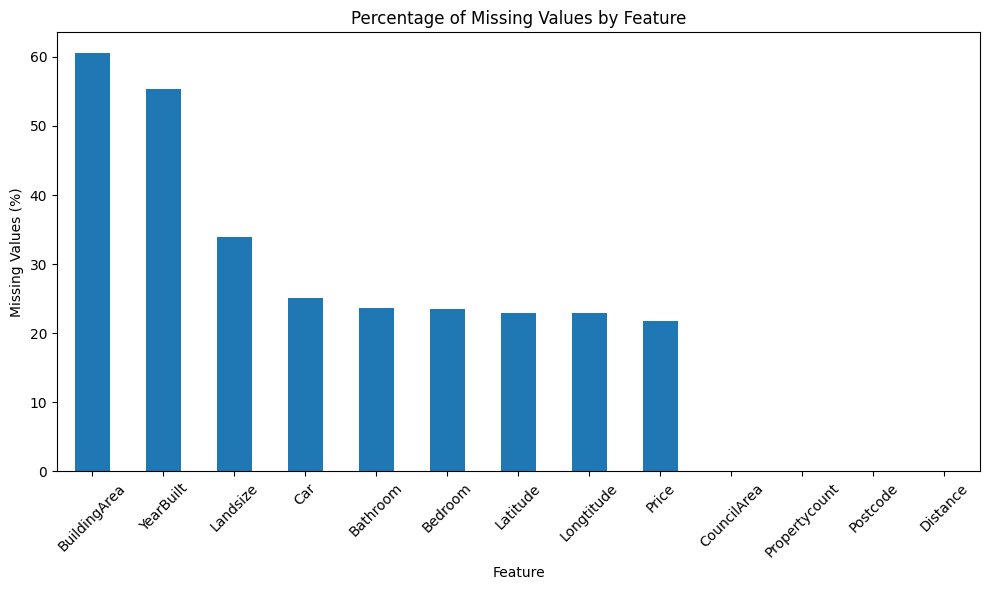

In [105]:
plt.figure(figsize=(10, 6))

missing_value_percentage.plot(kind="bar")

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Duplicate Record Analysis

The dataset is checked for completely duplicated rows to identify repeated observations.

In [106]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


### Data Type Analysis

The data types of all variables are inspected to identify numerical, categorical, date, and potentially malformed columns that require preprocessing.

In [107]:
df.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom          float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea      object
YearBuilt        float64
CouncilArea       object
Latitude         float64
Longtitude       float64
Regionname        object
Propertycount    float64
ParkingArea       object
Price            float64
dtype: object

### Cardinality Analysis

The number of unique values in each feature is examined to understand the cardinality of categorical variables and identify high-cardinality features that may require special treatment.

In [108]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Suburb: 351
Address: 34009
Rooms: 12
Type: 3
Method: 9
SellerG: 388
Date: 78
Distance: 215
Postcode: 211
Bedroom: 15
Bathroom: 11
Car: 15
Landsize: 1684
BuildingArea: 994
YearBuilt: 160
CouncilArea: 33
Latitude: 13402
Longtitude: 14524
Regionname: 8
Propertycount: 342
ParkingArea: 8
Price: 2871


### Investigation of BuildingArea

The BuildingArea feature is stored as an object rather than a numerical data type. Its values are inspected to determine the reason for the mixed data type and identify an appropriate cleaning strategy.

In [109]:
print("Data type:", df["BuildingArea"].dtype)

print("\nSample values:")
print(df["BuildingArea"].dropna().head(20))

Data type: object

Sample values:
0         inf
1         225
2          82
3         inf
4         122
5         263
6         inf
7         242
8         108
9         251
10        117
11    missing
12    missing
13         76
14        135
15    missing
16        399
17        inf
18        inf
19        inf
Name: BuildingArea, dtype: object


In [110]:
print("\nPython data types found:")
print(df["BuildingArea"].dropna().map(type).value_counts())


Python data types found:
BuildingArea
<class 'str'>      12930
<class 'float'>      830
Name: count, dtype: int64


In [111]:
print("\nSample unique values:")
print(df["BuildingArea"].dropna().unique()[:30])


Sample unique values:
['inf' '225' '82' '122' '263' '242' '108' '251' '117' 'missing' '76' '135'
 '399' '118' '103' '180' '123' '218' '129' '167' '154' '275' '121' '146'
 '125' '255' '94' '75' '254' '156']


### Target Variable Analysis

Price is the target variable for the regression task. Its data type, missing values, and descriptive statistics are examined before preprocessing.

In [112]:
print("Target variable: Price")
print("Data type:", df["Price"].dtype)
print("Missing values:", df["Price"].isnull().sum())

print("\nDescriptive statistics:")
print(df["Price"].describe())

Target variable: Price
Data type: float64
Missing values: 7610

Descriptive statistics:
count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64


## 2. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distributions, relationships, correlations, and potential anomalies within the Melbourne Housing dataset before applying preprocessing and machine learning models.

### 2.1 Target Variable Distribution

The distribution of the target variable, Price, is examined to understand its range, central tendency, and skewness.

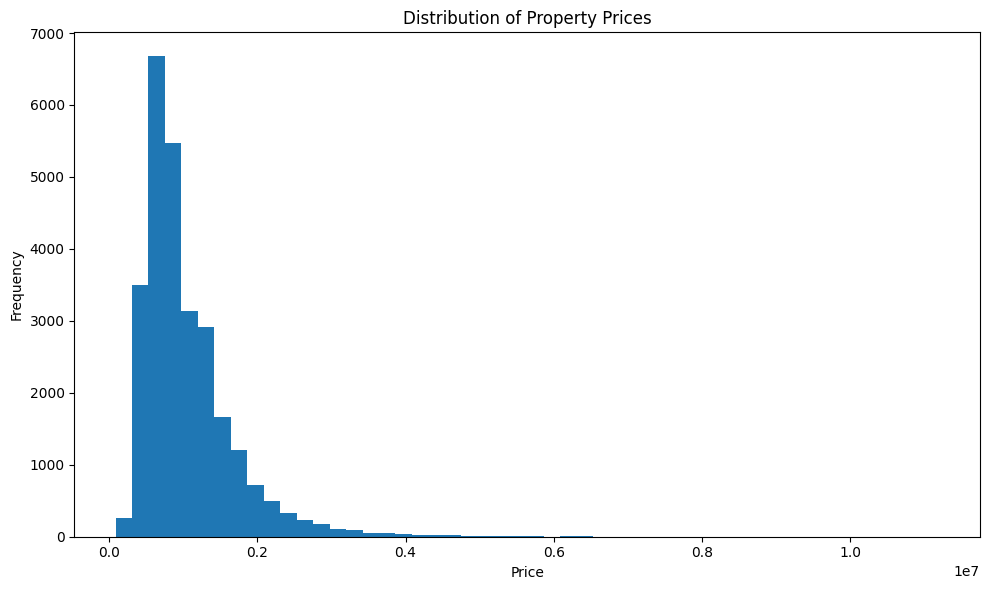

In [113]:
plt.figure(figsize=(10, 6))

plt.hist(df["Price"].dropna(), bins=50)

plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [114]:
df["Price"].describe()

count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64

### Insight Analysis


- The property price distribution is strongly right-skewed. Most properties are concentrated within the lower-to-middle price range, while a relatively small number of properties have substantially higher prices. These extreme values may have a strong influence on regression models and will therefore be investigated during the outlier analysis and preprocessing stage.

### 2.2 Numerical Feature Distributions

The distributions of numerical features are examined to identify their ranges, skewness, concentration, and potential unusual values.

In [115]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical features:")
print(list(numerical_columns))

Numerical features:
['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount', 'Price']


In [116]:
numerical_features = numerical_columns.drop("Price")

print("Number of numerical features:", len(numerical_features))
print(list(numerical_features))

Number of numerical features: 11
['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount']


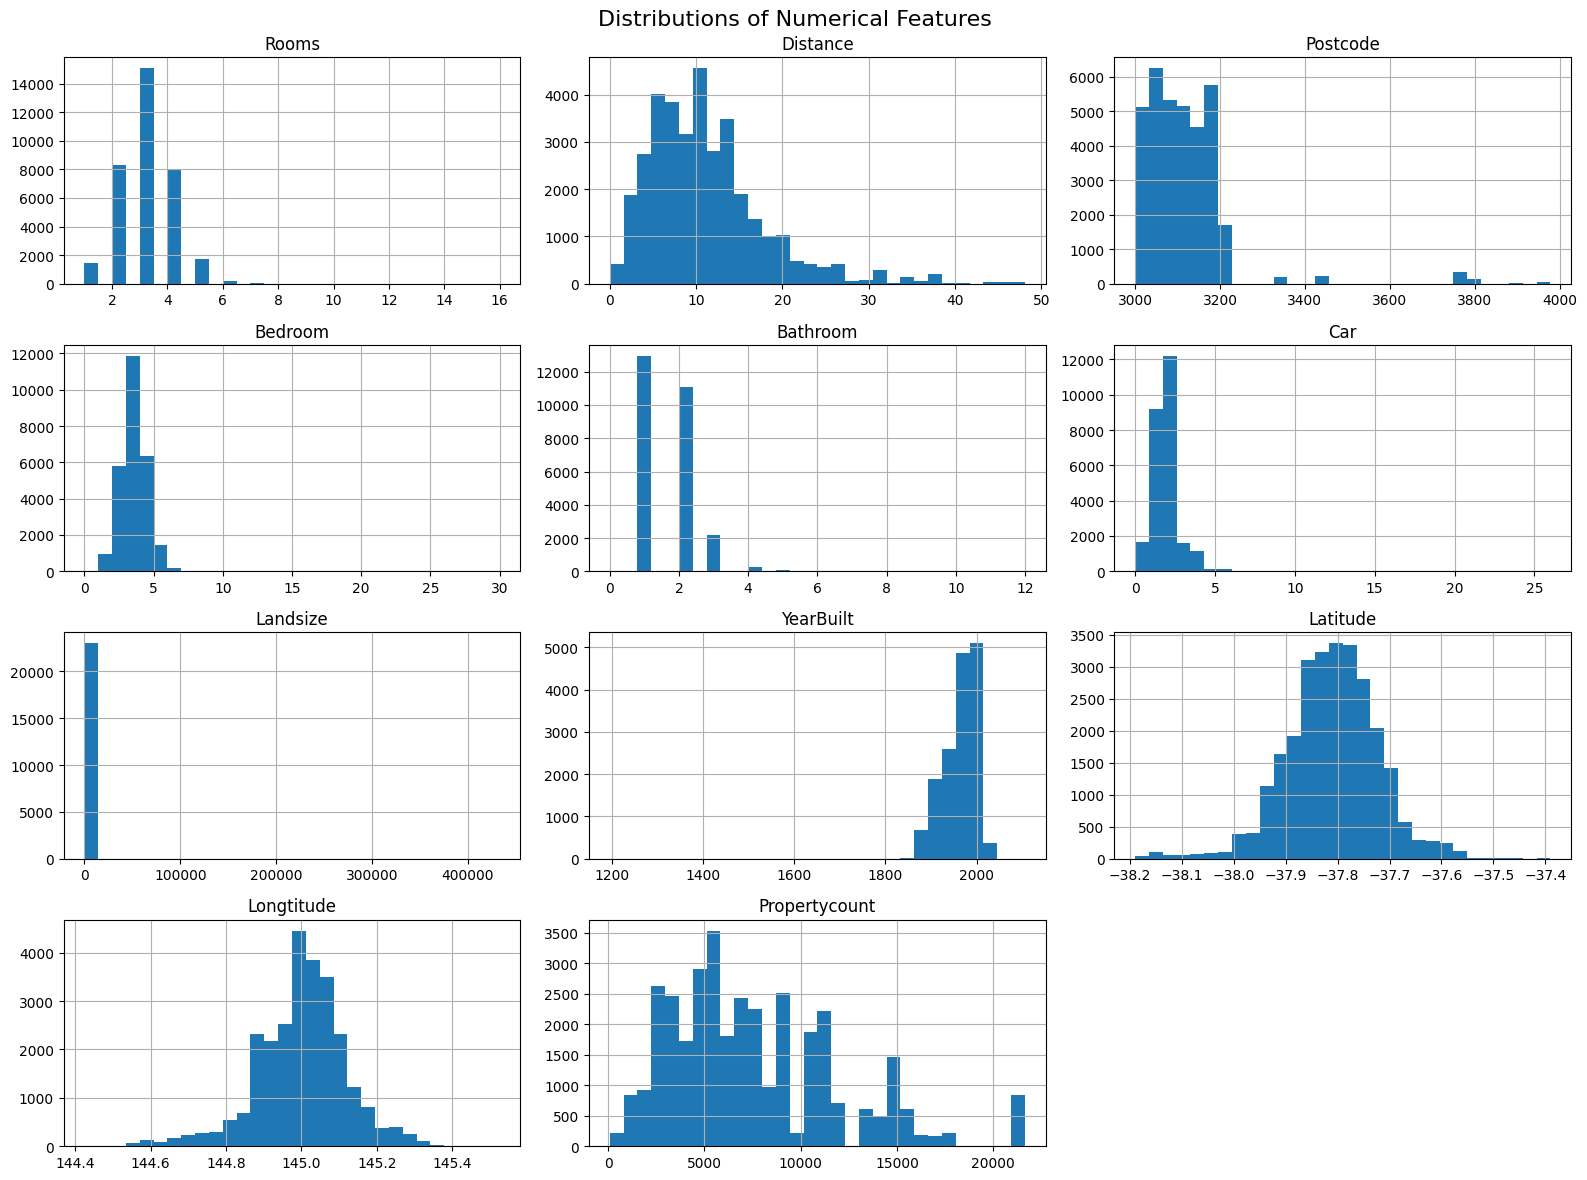

In [117]:
df[numerical_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Insight Analysis

- `Rooms`, `Bedroom`, `Bathroom`, and `Car` are concentrated around relatively small values, reflecting the typical characteristics of residential properties.
- `Distance` is concentrated mainly within the lower range, with fewer properties located substantially farther from the CBD.
- `Landsize` is highly right-skewed, with most properties having relatively small land areas and a small number of extremely large values. 
- `YearBuilt` is concentrated toward more recent construction years, although some unusually old values are present and should be examined for validity.
- `Latitude` and `Longtitude` are relatively concentrated, reflecting the geographic distribution of properties in the dataset.
- `Postcode` shows distinct groups of values rather than a continuous distribution, suggesting that it should be treated carefully during preprocessing rather than interpreted as a conventional continuous numerical feature.

### 2.3 Categorical Feature Distributions

The distributions of categorical variables are examined to understand the composition of the dataset and identify categories with very high or very low frequencies.

In [118]:
categorical_features = df.select_dtypes(include="object").columns

print("Categorical features:")
print(list(categorical_features))

Categorical features:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'BuildingArea', 'CouncilArea', 'Regionname', 'ParkingArea']


In [119]:
categorical_for_eda = [
    "Type",
    "Method",
    "Regionname",
    "ParkingArea"
]

for col in categorical_for_eda:
    print(f"\n{col}:")
    print(df[col].value_counts())


Type:
Type
h    23980
u     7297
t     3580
Name: count, dtype: int64

Method:
Method
S     19744
SP     5095
PI     4850
VB     3108
SN     1317
PN      308
SA      226
W       173
SS       36
Name: count, dtype: int64

Regionname:
Regionname
Southern Metropolitan         11836
Northern Metropolitan          9560
Western Metropolitan           6799
Eastern Metropolitan           4377
South-Eastern Metropolitan     1739
Eastern Victoria                228
Northern Victoria               203
Western Victoria                115
Name: count, dtype: int64

ParkingArea:
ParkingArea
Carport            6243
Detached Garage    6243
Attached Garage    6243
Indoor             5722
Parkade            4682
Underground        2602
Outdoor Stall      2081
Parking Pad        1041
Name: count, dtype: int64


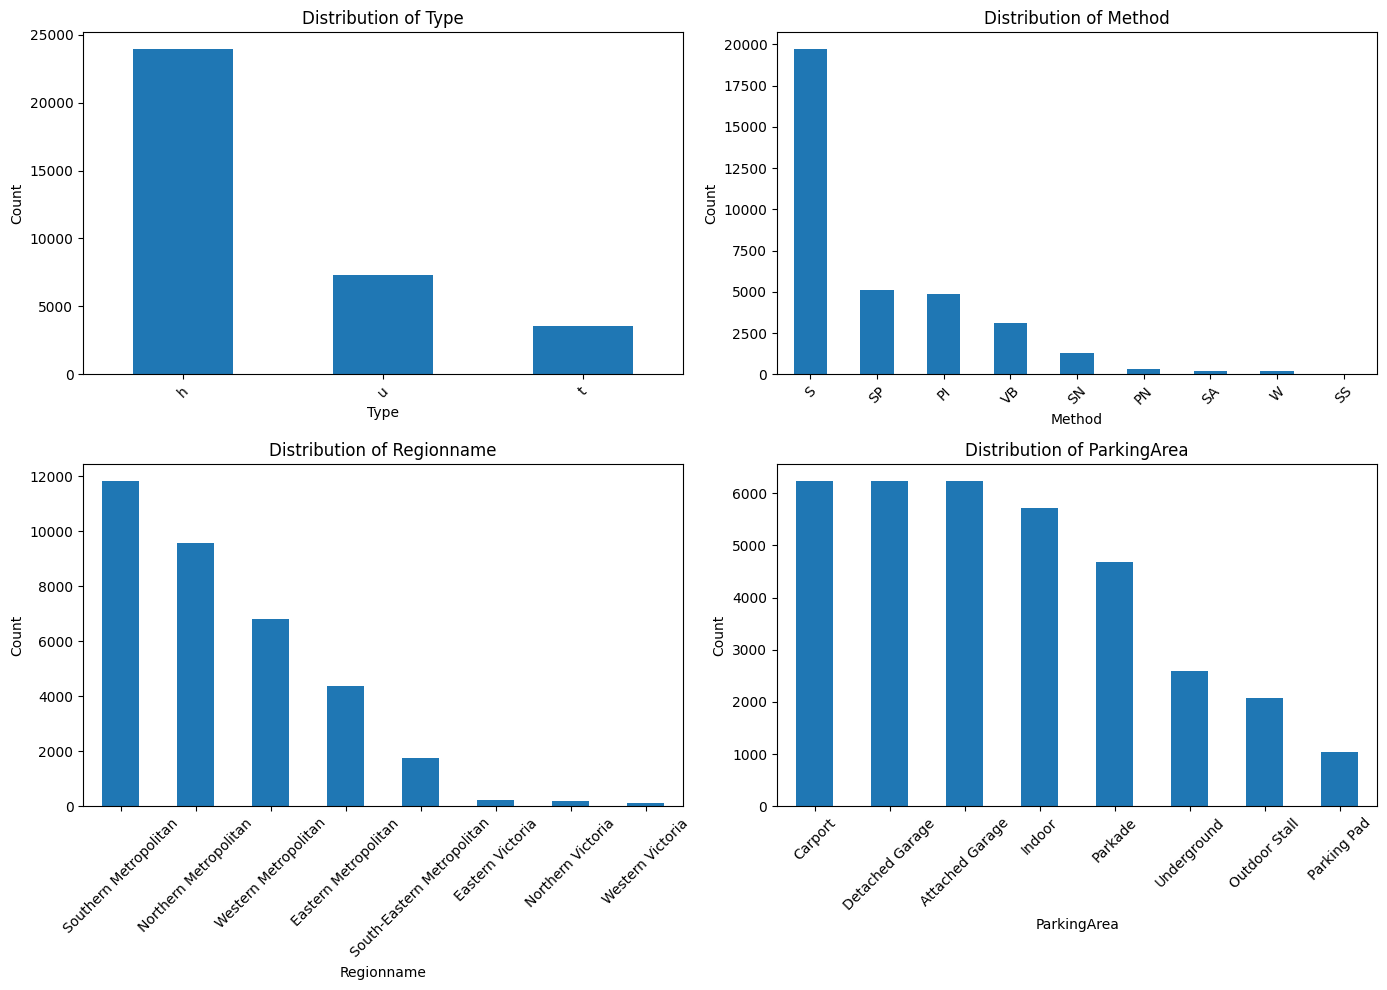

In [120]:
#Since there are a lot of a unique values in a few columns, we will only visualize the distributions of categorical features with a manageable number of unique values.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), categorical_for_eda):
    df[col].value_counts().plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Insight Analysis

- The `Type` feature is dominated by the `h` category, indicating that this property type represents the majority of observations in the dataset.
- The `Method` feature is also highly imbalanced, with the `S` category accounting for a large proportion of observations while several other categories occur much less frequently.
- `Regionname` has an uneven distribution, with metropolitan regions contributing substantially more observations than some of the smaller regions.
- `ParkingArea` has a comparatively broader distribution across its categories, although some categories are still more frequent than others.
- The categorical distributions indicate that categorical variables should be encoded appropriately while preserving their information for the regression models.

### 2.4 Correlation Analysis

A correlation matrix is used to examine the linear relationships between numerical variables and identify features that may have stronger relationships with the target variable.

In [121]:
correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

                  Rooms  Distance  Postcode   Bedroom  Bathroom       Car  \
Rooms          1.000000  0.271511  0.085890  0.946755  0.611826  0.393878   
Distance       0.271511  1.000000  0.481566  0.269524  0.126201  0.241835   
Postcode       0.085890  0.481566  1.000000  0.089292  0.120080  0.067886   
Bedroom        0.946755  0.269524  0.089292  1.000000  0.614892  0.388491   
Bathroom       0.611826  0.126201  0.120080  0.614892  1.000000  0.307518   
Car            0.393878  0.241835  0.067886  0.388491  0.307518  1.000000   
Landsize       0.037402  0.060862  0.040664  0.037019  0.036333  0.037829   
YearBuilt     -0.012749  0.323059  0.089805 -0.002022  0.167955  0.128702   
Latitude       0.004872 -0.100417 -0.231027  0.003447 -0.059183 -0.009020   
Longtitude     0.103235  0.200946  0.362895  0.106164  0.106531  0.047213   
Propertycount -0.071677 -0.018140  0.017108 -0.053451 -0.032887 -0.009617   
Price          0.465238 -0.211384  0.044950  0.430275  0.429878  0.201803   

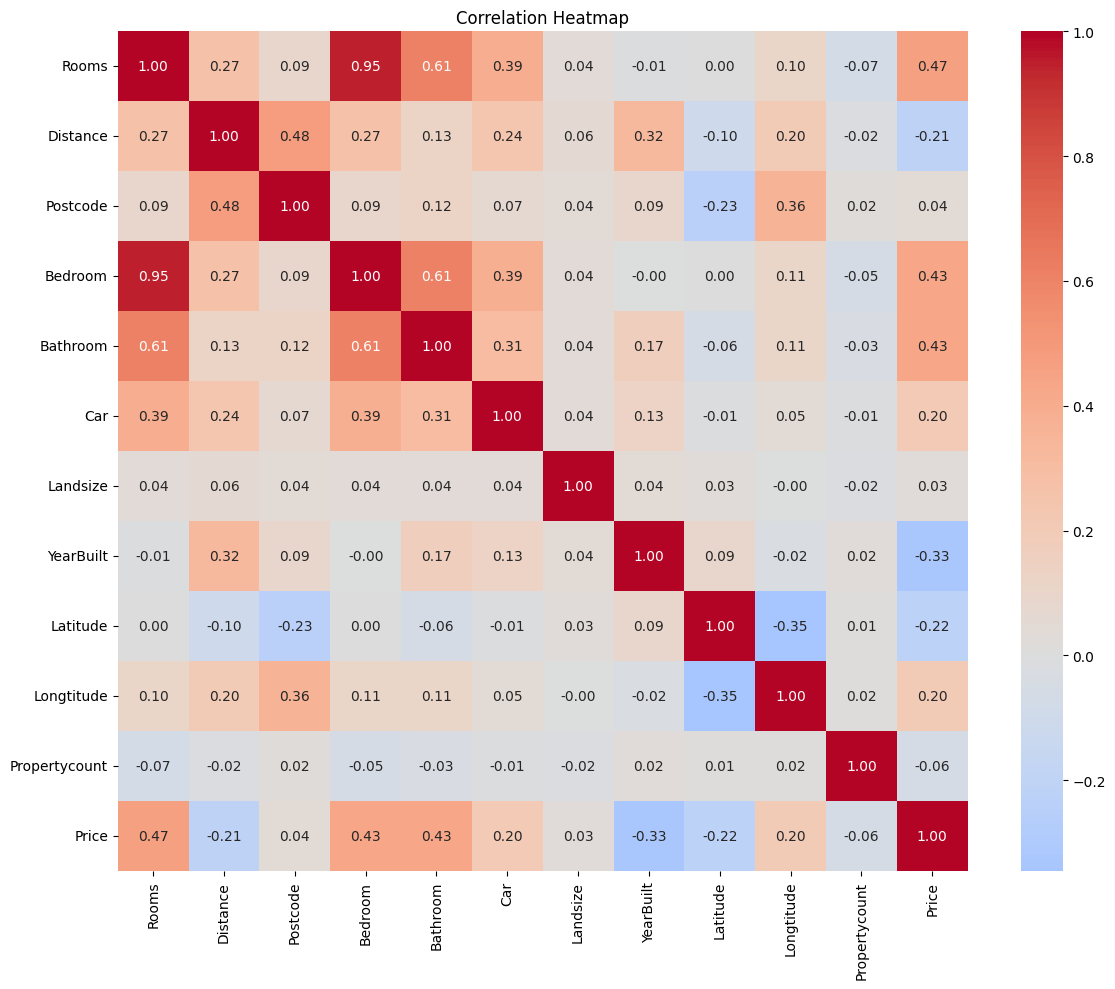

In [122]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Insight Analysis

- `Rooms` has the strongest positive linear correlation with `Price` among the numerical features, with a correlation of approximately 0.47. This indicates that properties with more rooms tend to have higher prices, although the relationship is not strong enough to explain price on its own.
- `Bedroom` and `Bathroom` also show moderate positive correlations with `Price`, both approximately 0.43.
- `Distance` has a moderate negative relationship with `Price` (approximately -0.21), suggesting that properties farther from the CBD tend to have lower prices.
- `YearBuilt` has a negative correlation with `Price` (approximately -0.33). This indicates that newer properties do not necessarily correspond to higher prices in this dataset and that other factors may influence this relationship.
- `Rooms` and `Bedroom` have a very strong correlation of approximately 0.95 with each other, indicating substantial overlap between these two features. This potential multicollinearity will be considered during feature engineering and model development.
- `Landsize` has a very weak linear correlation with `Price` despite its large range, suggesting that its relationship with price may be nonlinear or affected by extreme observations.
- Correlation measures only linear relationships, so features with relatively low correlation should not automatically be considered useless for nonlinear regression models.

### 2.5 Feature vs Target Relationships

Scatter plots are used to examine relationships between selected numerical features and property price.

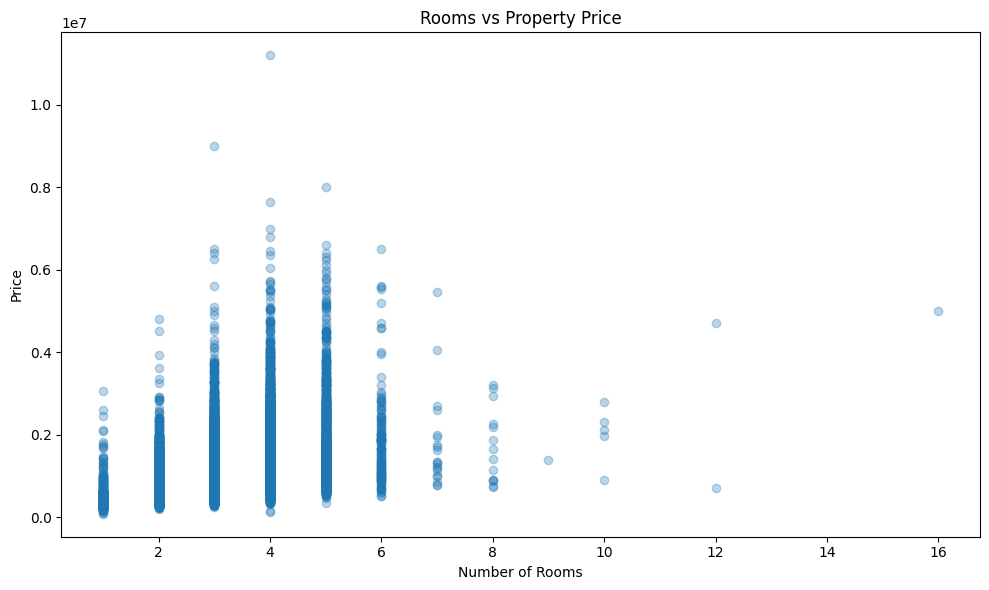

In [123]:
#Scatter plot to show the relationship between rooms and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Rooms"],
    df["Price"],
    alpha=0.3
)

plt.title("Rooms vs Property Price")
plt.xlabel("Number of Rooms")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

There is a generally positive relationship between the number of rooms and property price. Properties with more rooms tend to have higher possible prices, particularly when comparing properties with fewer rooms to those with four or more rooms. However, substantial variation exists within each room category, indicating that room count alone is insufficient to explain property prices. Several high-price observations are also visible and will be investigated during outlier analysis.

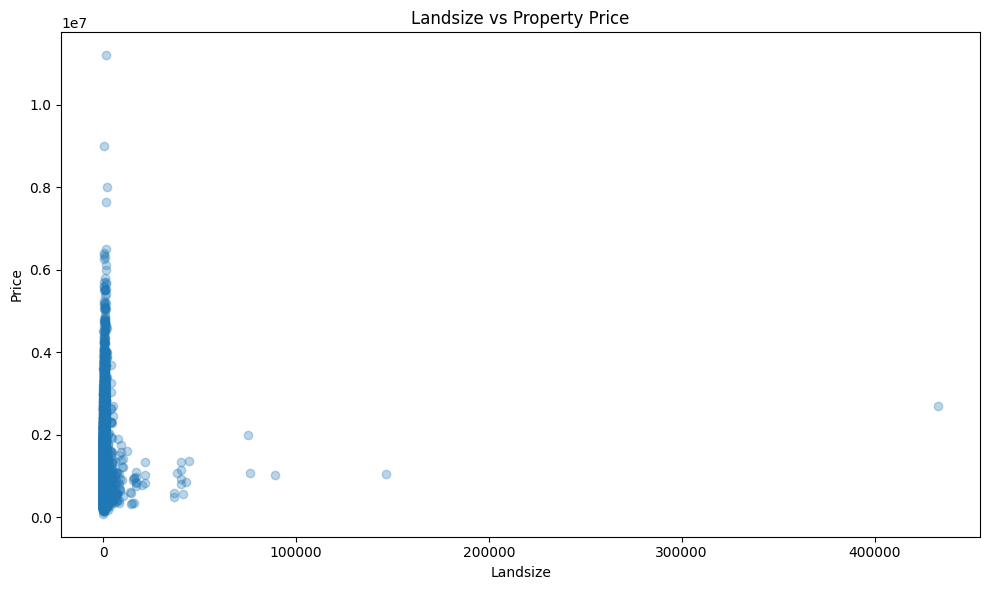

In [124]:
#Scatter plot to show the relationship between landsize and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Landsize"],
    df["Price"],
    alpha=0.3
)

plt.title("Landsize vs Property Price")
plt.xlabel("Landsize")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

The relationship between `Landsize` and `Price` is difficult to observe clearly because the feature is highly right-skewed and contains several extremely large land-area observations. Most properties are concentrated within a relatively small land-area range, while a small number of extreme observations extend far beyond the majority of the data. This indicates that `Landsize` requires further investigation during the outlier and preprocessing stages.

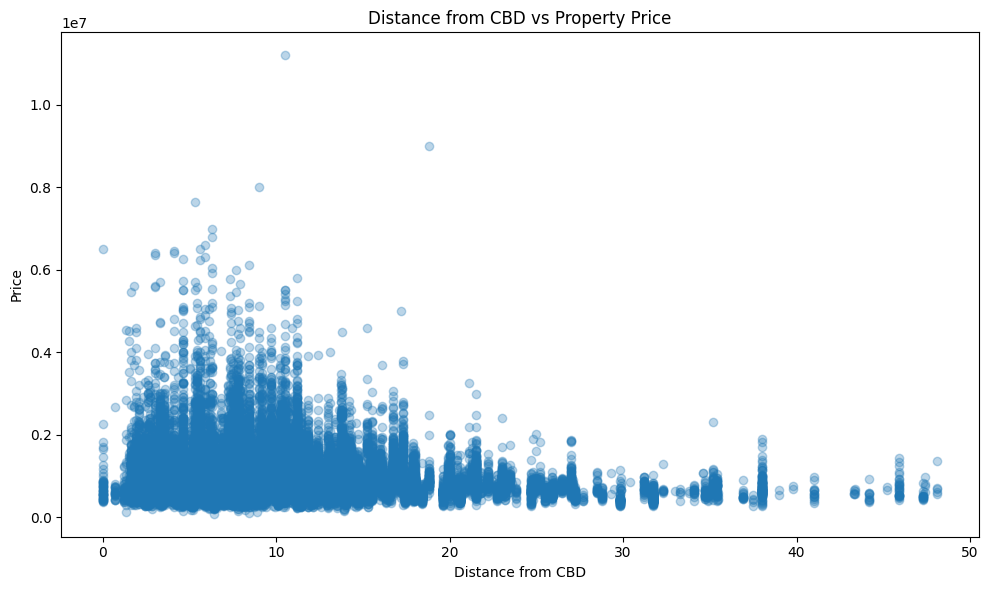

In [125]:
#Scatter plot to show the relationship between distance from CBD and property price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Distance"],
    df["Price"],
    alpha=0.3
)

plt.title("Distance from CBD vs Property Price")
plt.xlabel("Distance from CBD")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

### Insight Analysis

The scatter plot shows a generally negative relationship between distance from the CBD and property price. Higher-priced properties are more concentrated at lower distances, while properties farther from the CBD tend to have lower price ranges. However, substantial variation remains at most distances, indicating that location is only one of several factors influencing property prices.

## 3. Data Cleaning & Preprocessing

Based on the findings from the dataset audit and exploratory data analysis, the dataset is prepared for machine learning. This stage includes handling missing values, correcting data types, checking outliers, removing unsuitable features, engineering meaningful features, encoding categorical variables, and scaling numerical features where required.

In [126]:
# Create a copy of the original dataset for preprocessing
data = df.copy()

print("Original dataset shape:", data.shape)

Original dataset shape: (34857, 22)


### 3.1 Handling Missing Target Values

Rows with missing values in the target variable, `Price`, cannot be used for supervised regression because there is no known target value against which the model can learn or be evaluated. Therefore, these observations are removed rather than imputing the target.

In [127]:
before = len(data)

data = data.dropna(subset=["Price"]).copy()

after = len(data)

print("Rows before removing missing Price:", before)
print("Rows removed:", before - after)
print("Rows remaining:", after)

Rows before removing missing Price: 34857
Rows removed: 7610
Rows remaining: 27247


### 3.2 Correcting BuildingArea Data Type

`BuildingArea` represents the size of the property's building and should be numerical. The column was originally loaded as an object because it contains mixed values. Non-numeric values are converted to missing values using numeric coercion, after which the resulting missing values will be handled as part of the numerical-feature imputation strategy.

In [128]:
data["BuildingArea"] = pd.to_numeric(
    data["BuildingArea"],
    errors="coerce"
)

print("BuildingArea data type:", data["BuildingArea"].dtype)
print("Missing BuildingArea values:", data["BuildingArea"].isna().sum())

BuildingArea data type: float64
Missing BuildingArea values: 16586


### 3.3 Date Feature Processing

The `Date` column contains the property sale date. It is converted into a datetime representation so that the sale year can be extracted for feature engineering.

The sale year is used as an intermediate variable to calculate the property's age at the time of sale.

In [129]:
data["Date"] = pd.to_datetime(
    data["Date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

data["SaleYear"] = data["Date"].dt.year

print("Date data type:", data["Date"].dtype)
print("Missing Date values:", data["Date"].isna().sum())
print("Missing SaleYear values:", data["SaleYear"].isna().sum())
print(data[["Date", "SaleYear"]].head())

Date data type: datetime64[ns]
Missing Date values: 0
Missing SaleYear values: 0
        Date  SaleYear
1 2016-09-03      2016
2 2016-09-03      2016
3 2016-09-03      2016
5 2016-09-03      2016
6 2016-09-03      2016


### 3.4 Remaining Missing Values

After removing observations with missing target values and correcting the data type of `BuildingArea`, the remaining missing values are reviewed before selecting appropriate imputation strategies.

In [130]:
missing_after_cleaning = data.isnull().sum()

missing_after_cleaning = (
    missing_after_cleaning[missing_after_cleaning > 0]
    .sort_values(ascending=False)
)

print(missing_after_cleaning)

BuildingArea     16586
YearBuilt        15163
Landsize          9265
Car               6824
Bathroom          6447
Bedroom           6441
Latitude          6254
Longtitude        6254
CouncilArea          3
Propertycount        3
Distance             1
Postcode             1
dtype: int64


### 3.5 Validity Checks

Numerical variables are checked for impossible or potentially invalid values. These checks distinguish genuine extreme observations from values that may represent data-entry or data-quality issues.

In [131]:
checks = {
    "Rooms <= 0": (data["Rooms"] <= 0).sum(),
    "Bedroom < 0": (data["Bedroom"] < 0).sum(),
    "Bathroom < 0": (data["Bathroom"] < 0).sum(),
    "Car < 0": (data["Car"] < 0).sum(),
    "Landsize < 0": (data["Landsize"] < 0).sum(),
    "BuildingArea < 0": (data["BuildingArea"] < 0).sum(),
    "YearBuilt < 1800": (data["YearBuilt"] < 1800).sum(),
    "YearBuilt > 2026": (data["YearBuilt"] > 2026).sum()
}

pd.Series(checks)

Rooms <= 0          0
Bedroom < 0         0
Bathroom < 0        0
Car < 0             0
Landsize < 0        0
BuildingArea < 0    0
YearBuilt < 1800    1
YearBuilt > 2026    0
dtype: int64

In [132]:
# Treat clearly invalid construction years as missing
data.loc[data["YearBuilt"] < 1800, "YearBuilt"] = np.nan

print("Invalid YearBuilt values treated as missing:",
      (data["YearBuilt"].isna()).sum())

Invalid YearBuilt values treated as missing: 15164


### 3.6 Outlier Detection

Potential outliers in numerical features are identified using the Interquartile Range (IQR) method. These observations will be investigated before deciding whether they should be retained, transformed, capped, or removed.

In [133]:
outlier_columns = [
    "Rooms",
    "Bedroom",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Price"
]

outlier_summary = {}

for col in outlier_columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((data[col] < lower) | (data[col] > upper)).sum()

    outlier_summary[col] = {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": count
    }

outlier_summary = pd.DataFrame(outlier_summary).T

outlier_summary

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
Rooms,2.0,4.0,2.0,-1.0,7.0,23.0
Bedroom,2.0,4.0,2.0,-1.0,7.0,19.0
Bathroom,1.0,2.0,1.0,-0.5,3.5,238.0
Car,1.0,2.0,1.0,-0.5,3.5,1171.0
Landsize,219.0,664.0,445.0,-448.5,1331.5,453.0
BuildingArea,100.0,182.0,82.0,-23.0,305.0,514.0
YearBuilt,1950.0,2000.0,50.0,1875.0,2075.0,27.0
Distance,6.4,14.0,7.6,-5.0,25.4,1188.0
Price,635000.0,1295000.0,660000.0,-355000.0,2285000.0,1278.0


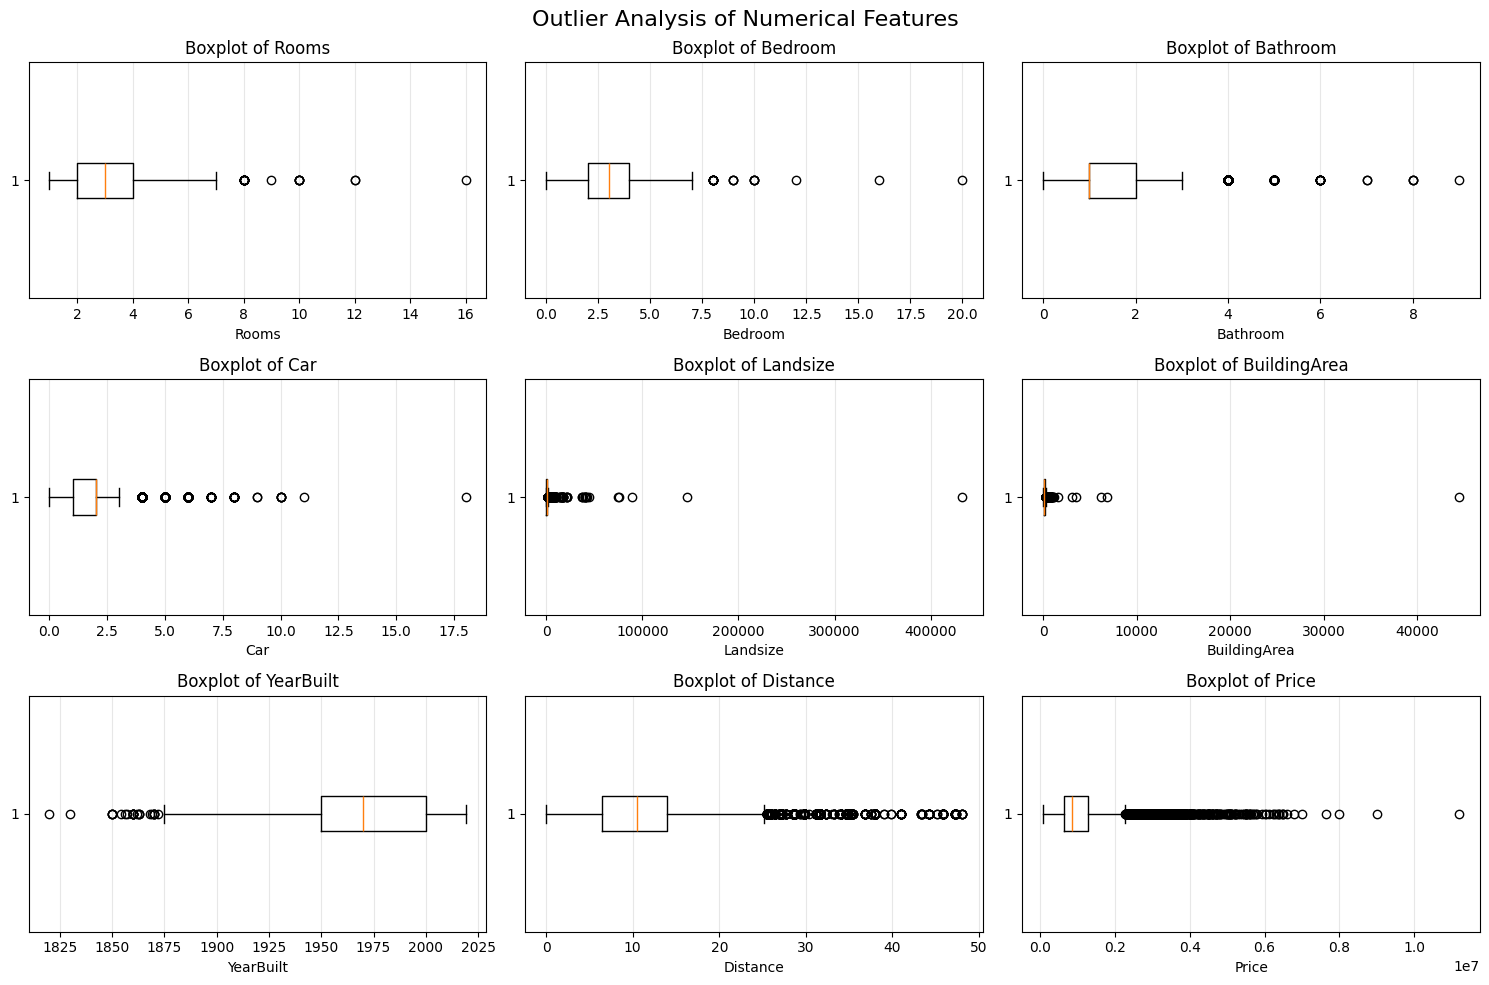

In [134]:
import matplotlib.pyplot as plt

boxplot_columns = [
    "Rooms",
    "Bedroom",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Distance",
    "Price"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for ax, col in zip(axes.flat, boxplot_columns):
    ax.boxplot(data[col].dropna(), vert=False)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Outlier Analysis of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### 3.7 Feature Engineering

A meaningful domain-based feature, `PropertyAge`, is created to capture the age of a property at the time of sale. It is calculated as the difference between the sale year and the property's construction year.


Property age may capture effects related to depreciation, maintenance, architectural age, and buyer preferences that are not represented directly by `YearBuilt` alone. This feature may therefore provide the regression models with a more directly interpretable measure of the property's age at the time of sale.

In [135]:
data["PropertyAge"] = data["SaleYear"] - data["YearBuilt"]

print(data["PropertyAge"].describe())

print("Missing PropertyAge values:", data["PropertyAge"].isna().sum())

count    12083.000000
mean        50.095672
std         36.029590
min         -2.000000
25%         17.000000
50%         47.000000
75%         68.000000
max        197.000000
Name: PropertyAge, dtype: float64
Missing PropertyAge values: 15164


In [136]:
data.loc[
    data["PropertyAge"] > 150,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
100,2016-09-03,2016,1830.0,186.0
636,2016-12-03,2016,1863.0,153.0
1791,2016-05-07,2016,1856.0,160.0
3377,2016-12-10,2016,1860.0,156.0
9630,2017-12-09,2017,1860.0,157.0
10371,2017-11-11,2017,1860.0,157.0
10785,2017-08-12,2017,1862.0,155.0
13882,2016-08-13,2016,1854.0,162.0
15379,2017-07-15,2017,1860.0,157.0
18993,2017-06-17,2017,1863.0,154.0


In [137]:
invalid_age = data[data["PropertyAge"] < 0]

print("Number of negative PropertyAge values:", len(invalid_age))

invalid_age[["Date", "SaleYear", "YearBuilt", "PropertyAge"]]

Number of negative PropertyAge values: 7


,Date,SaleYear,YearBuilt,PropertyAge
352,2016-12-03,2016,2017.0,-1.0
17807,2018-03-17,2018,2019.0,-1.0
19585,2016-09-17,2016,2017.0,-1.0
24997,2016-04-23,2016,2017.0,-1.0
27420,2016-09-24,2016,2018.0,-2.0
32022,2016-05-28,2016,2017.0,-1.0
34817,2016-07-30,2016,2017.0,-1.0


In [138]:
data.loc[
    data["PropertyAge"] < 0,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
352,2016-12-03,2016,2017.0,-1.0
17807,2018-03-17,2018,2019.0,-1.0
19585,2016-09-17,2016,2017.0,-1.0
24997,2016-04-23,2016,2017.0,-1.0
27420,2016-09-24,2016,2018.0,-2.0
32022,2016-05-28,2016,2017.0,-1.0
34817,2016-07-30,2016,2017.0,-1.0


In [139]:
data.loc[
    data["PropertyAge"] > 150,
    ["Date", "SaleYear", "YearBuilt", "PropertyAge"]
]

,Date,SaleYear,YearBuilt,PropertyAge
100,2016-09-03,2016,1830.0,186.0
636,2016-12-03,2016,1863.0,153.0
1791,2016-05-07,2016,1856.0,160.0
3377,2016-12-10,2016,1860.0,156.0
9630,2017-12-09,2017,1860.0,157.0
10371,2017-11-11,2017,1860.0,157.0
10785,2017-08-12,2017,1862.0,155.0
13882,2016-08-13,2016,1854.0,162.0
15379,2017-07-15,2017,1860.0,157.0
18993,2017-06-17,2017,1863.0,154.0


In [140]:
# Treat logically invalid negative property ages as missing
data.loc[data["PropertyAge"] < 0, "PropertyAge"] = np.nan

print("Missing PropertyAge values after validity correction:",
      data["PropertyAge"].isna().sum())

Missing PropertyAge values after validity correction: 15171


### 3.8 Handling Date-Derived Features

The original `Date` column was converted to a datetime representation and `SaleYear` was extracted as an intermediate feature for calculating `PropertyAge`.

Since `PropertyAge` captures the relevant temporal information needed for modelling, the original `Date` and intermediate `SaleYear` features are removed from the modelling dataset.

In [141]:
# Remove the original date and highly incomplete date-derived features
data = data.drop(columns=["Date", "SaleYear"])

print("Dataset shape after date feature handling:", data.shape)
print("\nRemaining columns:")
print(data.columns.tolist())

Dataset shape after date feature handling: (27247, 22)

Remaining columns:
['Suburb', 'Address', 'Rooms', 'Type', 'Method', 'SellerG', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Latitude', 'Longtitude', 'Regionname', 'Propertycount', 'ParkingArea', 'Price', 'PropertyAge']


## 4. Train-Test Split and Preprocessing

The cleaned dataset is prepared for machine learning by separating the predictor variables from the target variable. The dataset is then divided into training and testing subsets using an 80:20 split. Preprocessing transformations will be fitted only on the training data to prevent data leakage.

### 4.1 Feature and Target Separation

The cleaned dataset is divided into predictor variables (`X`) and the target variable (`y`). The `Price` column is used as the target for the regression task. The `Address` column is excluded from modelling because of its extremely high cardinality, while other location-related features are retained.

In [142]:
# Replace infinite values with NaN so they can be handled by the imputer
data = data.replace([np.inf, -np.inf], np.nan)

print("Infinite values remaining:")
print(np.isinf(data.select_dtypes(include=np.number)).sum().sum())

Infinite values remaining:
0


In [143]:
# Separate features and target
# Address is excluded because of its extremely high cardinality.
X = data.drop(columns=["Price", "Address"])
y = data["Price"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (27247, 20)
Target shape: (27247,)


### 4.2 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split. A fixed random state is used to ensure that the split is reproducible. The test set is kept separate from the preprocessing and model-fitting stages and will be used only for final model evaluation.

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training set shape: (21797, 20)
Testing set shape: (5450, 20)
Training target shape: (21797,)
Testing target shape: (5450,)


### 4.3 Numerical and Categorical Feature Identification

The predictor variables are separated into numerical and categorical features based on their data types. The `Postcode` feature is treated as categorical because it represents a geographical location identifier rather than a continuous numerical quantity.

In [145]:
# Treat Postcode as a categorical location feature
X_train["Postcode"] = X_train["Postcode"].astype("object")
X_test["Postcode"] = X_test["Postcode"].astype("object")

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Rooms', 'Distance', 'Bedroom', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Latitude', 'Longtitude', 'Propertycount', 'PropertyAge']

Categorical features:
['Suburb', 'Type', 'Method', 'SellerG', 'Postcode', 'CouncilArea', 'Regionname', 'ParkingArea']


### 4.4 Preprocessing Pipeline

Numerical features are processed using median imputation followed by standardization. Categorical features are processed using most-frequent imputation followed by one-hot encoding. The preprocessing steps are implemented using a pipeline so that all transformations are fitted only on the training data, preventing data leakage.

In [146]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [147]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

In [148]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

### 4.5 Fit and Transform the Data

The preprocessing transformer is fitted only on the training data. The learned transformations are then applied to both the training and testing sets. This ensures that information from the testing set does not influence imputation, scaling, or categorical encoding, thereby preventing data leakage.

In [149]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (21797, 954)
Processed testing shape: (5450, 954)


### 4.6 Verification of Preprocessed Data

The preprocessing pipeline is fitted using only the training data and then applied to both the training and testing sets. The transformed datasets are checked to ensure that they have the same feature dimensions and contain no missing or infinite values.

In [150]:
from scipy import sparse

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

if sparse.issparse(X_train_processed):
    print("Processed training data is sparse:", True)
    print("Processed testing data is sparse:", True)
    
    print(
        "Non-finite values in training data:",
        np.isfinite(X_train_processed.data).sum()
        != X_train_processed.data.size
    )
    
    print(
        "Non-finite values in testing data:",
        np.isfinite(X_test_processed.data).sum()
        != X_test_processed.data.size
    )
else:
    print("Processed training data is sparse:", False)
    print("Processed testing data is sparse:", False)
    
    print(
        "Non-finite values in training data:",
        np.isfinite(X_train_processed).sum()
        != X_train_processed.size
    )
    
    print(
        "Non-finite values in testing data:",
        np.isfinite(X_test_processed).sum()
        != X_test_processed.size
    )

Processed training shape: (21797, 954)
Processed testing shape: (5450, 954)
Processed training data is sparse: True
Processed testing data is sparse: True
Non-finite values in training data: False
Non-finite values in testing data: False


## 5. Regression Modelling

The preprocessed training data is used to train and compare the required regression algorithms. The models are evaluated on the same held-out testing set using R², RMSE, and MAE to ensure a consistent comparison of their predictive performance.

### 5.1 Model Setup and Evaluation Metrics

The regression models are evaluated using three performance metrics: R², RMSE, and MAE. R² measures the proportion of variance in the target variable explained by the model. RMSE measures the square root of the average squared prediction error and gives greater weight to larger errors, while MAE measures the average absolute prediction error.

A common evaluation function is used for all regression models to ensure that their performance is compared consistently.

In [151]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [152]:
def evaluate_model(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return {
        "Model": model_name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    }

In [153]:
results = []

### 5.2 Linear Regression

Linear Regression is used as the baseline regression model. It assumes a linear relationship between the predictor variables and the target variable. Its performance provides a reference point for evaluating the more complex regression algorithms.

In [154]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

y_pred_linear = linear_model.predict(X_test_processed)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    y_pred_linear
)

results.append(linear_results)

print(linear_results)

{'Model': 'Linear Regression', 'R²': 0.6831492750603996, 'RMSE': np.float64(350550.69944912224), 'MAE': 231653.13954628707}


### 5.3 Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization. The regularization term penalizes large model coefficients, helping to reduce overfitting and improve model stability when predictors are correlated or when the feature space contains many variables.

In [155]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, y_train)

y_pred_ridge = ridge_model.predict(X_test_processed)

ridge_results = evaluate_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
)

results.append(ridge_results)

print(ridge_results)

{'Model': 'Ridge Regression', 'R²': 0.6865909244703025, 'RMSE': np.float64(348641.65108678845), 'MAE': 230611.82983004532}


### 5.4 Lasso Regression

Lasso Regression applies L1 regularization to the linear regression objective. The L1 penalty can shrink some coefficients to zero, which can effectively perform feature selection and reduce the influence of less useful predictors in the high-dimensional feature space.

In [156]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(
    alpha=10.0,
    max_iter=10000,
    tol=1e-3,
    selection="random",
    random_state=42
)

lasso_model.fit(X_train_processed, y_train)

y_pred_lasso = lasso_model.predict(X_test_processed)

lasso_results = evaluate_model(
    "Lasso Regression",
    y_test,
    y_pred_lasso
)

results.append(lasso_results)

print(lasso_results)

{'Model': 'Lasso Regression', 'R²': 0.6854514269652235, 'RMSE': np.float64(349274.8743590813), 'MAE': 230636.28964582348}


### 5.5 ElasticNet Regression

ElasticNet Regression combines L1 and L2 regularization. The L1 component can shrink some coefficients to zero, providing a degree of feature selection, while the L2 component helps stabilize the model when predictors are correlated. ElasticNet is particularly useful for high-dimensional datasets containing correlated predictors.

In [157]:
from sklearn.linear_model import ElasticNet

elasticnet_model = ElasticNet(
    alpha=10.0,
    l1_ratio=0.5,
    max_iter=10000,
    tol=1e-3,
    selection="random",
    random_state=42
)

elasticnet_model.fit(X_train_processed, y_train)

y_pred_elasticnet = elasticnet_model.predict(X_test_processed)

elasticnet_results = evaluate_model(
    "ElasticNet Regression",
    y_test,
    y_pred_elasticnet
)

results.append(elasticnet_results)

print(elasticnet_results)

{'Model': 'ElasticNet Regression', 'R²': 0.23088474221261224, 'RMSE': np.float64(546159.1311421267), 'MAE': 384473.9341088468}


### 5.6 Polynomial Regression

Polynomial Regression extends linear regression by introducing polynomial terms of the predictor variables, allowing the model to represent nonlinear relationships. Since the common preprocessing produces a high-dimensional 954-feature sparse matrix due to one-hot encoding, polynomial expansion is applied only to selected continuous numerical features to avoid an unnecessary and computationally excessive expansion of the categorical feature space. The remaining preprocessed categorical features are retained in their original one-hot encoded form.

In [158]:
from sklearn.preprocessing import PolynomialFeatures
from scipy import sparse

# Select continuous features for polynomial expansion
polynomial_features = [
    "Rooms",
    "Distance",
    "Landsize",
    "BuildingArea",
    "PropertyAge"
]

# Get their positions in the numerical part of the processed matrix
polynomial_indices = [
    numerical_features.index(feature)
    for feature in polynomial_features
]

print("Polynomial features:")
print(polynomial_features)

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

# Numerical features are stored first in X_processed
X_train_num = X_train_processed[:, :len(numerical_features)]
X_test_num = X_test_processed[:, :len(numerical_features)]

# Extract selected numerical features
X_train_poly_input = X_train_num[:, polynomial_indices]
X_test_poly_input = X_test_num[:, polynomial_indices]

# Generate degree-2 polynomial terms
X_train_poly = poly.fit_transform(X_train_poly_input)
X_test_poly = poly.transform(X_test_poly_input)

print("Polynomial training shape:", X_train_poly.shape)
print("Polynomial testing shape:", X_test_poly.shape)

# Keep all other preprocessed features
remaining_indices = [
    i for i in range(X_train_processed.shape[1])
    if i not in polynomial_indices
]

X_train_remaining = X_train_processed[:, remaining_indices]
X_test_remaining = X_test_processed[:, remaining_indices]

# Combine polynomial terms with the remaining preprocessed features
X_train_poly_final = sparse.hstack(
    [X_train_poly, X_train_remaining],
    format="csr"
)

X_test_poly_final = sparse.hstack(
    [X_test_poly, X_test_remaining],
    format="csr"
)

print("Final polynomial training shape:", X_train_poly_final.shape)
print("Final polynomial testing shape:", X_test_poly_final.shape)


from sklearn.linear_model import LinearRegression

polynomial_model = LinearRegression()

polynomial_model.fit(
    X_train_poly_final,
    y_train
)

y_pred_polynomial = polynomial_model.predict(
    X_test_poly_final
)

polynomial_results = evaluate_model(
    "Polynomial Regression",
    y_test,
    y_pred_polynomial
)

results.append(polynomial_results)

print(polynomial_results)

Polynomial features:
['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'PropertyAge']
Polynomial training shape: (21797, 20)
Polynomial testing shape: (5450, 20)
Final polynomial training shape: (21797, 969)
Final polynomial testing shape: (5450, 969)
{'Model': 'Polynomial Regression', 'R²': 0.7063191728147618, 'RMSE': np.float64(337490.29049051035), 'MAE': 218440.20788239292}


### 5.7 Decision Tree Regression

Decision Tree Regression predicts the target variable by recursively splitting the feature space into regions based on feature values. Each split is selected to reduce prediction error within the resulting regions. Decision trees can model nonlinear relationships and interactions between features without requiring the features to be normally distributed.

In [159]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train_processed,
    y_train
)

y_pred_tree = tree_model.predict(
    X_test_processed
)

tree_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    y_pred_tree
)

results.append(tree_results)

print(tree_results)

{'Model': 'Decision Tree Regressor', 'R²': 0.6484161686003627, 'RMSE': np.float64(369264.81872600963), 'MAE': 220509.08391437313}


### 5.8 Random Forest Regression

Random Forest Regression is an ensemble learning method that combines predictions from multiple decision trees. Each tree is trained using different samples and feature subsets, and their predictions are aggregated to produce the final prediction. Random Forest can capture nonlinear relationships and feature interactions while generally reducing the overfitting associated with a single decision tree.

In [160]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

y_pred_random_forest = random_forest_model.predict(
    X_test_processed
)

random_forest_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    y_pred_random_forest
)

results.append(random_forest_results)

print(random_forest_results)

{'Model': 'Random Forest Regressor', 'R²': 0.7958338604943312, 'RMSE': np.float64(281394.3310475196), 'MAE': 164873.0158540265}


### 5.9 Gradient Boosting Regression

Gradient Boosting Regression is an ensemble learning method that builds a sequence of decision trees, where each new tree attempts to reduce the errors made by the previous trees. The model combines the predictions of these weak learners to produce a stronger overall prediction.

The learning rate controls how much each new tree contributes to the final model. A smaller learning rate generally requires more trees but can provide more gradual learning, while a larger learning rate allows faster learning but may increase the risk of overfitting.

### 5.9.1 Baseline Model

In [161]:
from sklearn.ensemble import GradientBoostingRegressor
# Convert sparse matrices to dense arrays for Gradient Boosting
X_train_gb = X_train_processed.toarray()
X_test_gb = X_test_processed.toarray()

In [162]:
# Create the baseline Gradient Boosting Regressor
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
# Train the baseline model
gradient_boosting_model.fit(
    X_train_gb,
    y_train
)
# Make predictions
y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_test_gb
)
# Evaluate the baseline model
gradient_boosting_baseline_results = evaluate_model(
    "Gradient Boosting Regressor - Baseline",
    y_test,
    y_pred_gradient_boosting
)
print(gradient_boosting_baseline_results)

{'Model': 'Gradient Boosting Regressor - Baseline', 'R²': 0.7657291764564192, 'RMSE': np.float64(301427.3028729681), 'MAE': 188323.5251238216}


### 5.9.2 Hyperparameter Tuning using GridSearchCV

To improve the Gradient Boosting Regressor, GridSearchCV is used to select the best learning rate based only on the training data.

The learning rate determines how strongly each new tree contributes to the model. Several learning rates are evaluated while keeping the other model parameters fixed.

Three-fold cross-validation is used during the grid search so that the hyperparameter selection does not depend on the held-out test set. The test set is kept untouched until the final evaluation.

In [163]:
from sklearn.model_selection import GridSearchCV
# Parameter grid for Gradient Boosting
param_grid_gb = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2]
}
# Base Gradient Boosting model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42
)
# GridSearchCV using only the training data
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
# Perform grid search on the training data
grid_search_gb.fit(
    X_train_gb,
    y_train
)
print("Best Parameters:", grid_search_gb.best_params_)
print("Best CV RMSE:", -grid_search_gb.best_score_)

Best Parameters: {'learning_rate': 0.2}
Best CV RMSE: 321402.20041376265


In [164]:
# Select the best Gradient Boosting model found by GridSearchCV
best_gradient_boosting_model = grid_search_gb.best_estimator_
# Make predictions on the untouched test set
y_pred_gradient_boosting = best_gradient_boosting_model.predict(
    X_test_gb
)
# Evaluate the final tuned model
gradient_boosting_results = evaluate_model(
    "Gradient Boosting Regressor",
    y_test,
    y_pred_gradient_boosting
)
print(gradient_boosting_results)

{'Model': 'Gradient Boosting Regressor', 'R²': 0.7823673550588268, 'RMSE': np.float64(290526.33502023027), 'MAE': 181163.8213340266}


In [165]:
# Remove any previous Gradient Boosting results
results = [
    result for result in results
    if "Gradient Boosting" not in result["Model"]
]
# Add the final tuned Gradient Boosting result
results.append(gradient_boosting_results)

### 5.9.3 Final Evaluation

The tuned Gradient Boosting Regressor achieved an R² of **0.7824**, with an RMSE of **290,526.34** and an MAE of **181,163.82** on the held-out test set.

GridSearchCV selected a learning rate of **0.2** using three-fold cross-validation on the training data. The held-out test set was kept separate during hyperparameter tuning.

Compared with the baseline Gradient Boosting model, which achieved an R² of approximately **0.7657**, the tuned model achieved a higher R² and lower prediction errors. This indicates that the selected learning rate improved the model's performance on the held-out test data.

### 5.10 Support Vector Regression (SVR)

Support Vector Regression (SVR) is a regression algorithm that finds a function
that fits the data within a specified tolerance while controlling model
complexity.

SVR is sensitive to feature scale. The existing preprocessing pipeline is used
before training. Since the target variable (Price) contains large values,
target scaling is also applied before fitting the SVR model. Predictions are
converted back to the original price scale before evaluation.

### 5.10.1 Baseline Model

In [166]:

# 10. Support Vector Regression (SVR)


from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler


# 10.1 Target Scaling for SVR


target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()


# 10.2 SVR Baseline Model


svr_model = SVR(
    kernel="rbf",
    C=1.0
)

svr_model.fit(
    X_train_processed,
    y_train_scaled
)

y_pred_svr_scaled = svr_model.predict(
    X_test_processed
)

y_pred_svr = target_scaler.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

svr_baseline_results = evaluate_model(
    "SVR - Baseline",
    y_test,
    y_pred_svr
)

print(svr_baseline_results)

{'Model': 'SVR - Baseline', 'R²': 0.7878499772167681, 'RMSE': np.float64(286843.5091029293), 'MAE': 168973.09489580276}


### 5.10.2 Hyperparameter Tuning

SVR performance depends on hyperparameters such as C and kernel.

GridSearchCV is used to tune these parameters using 3-fold cross-validation.
Since SVR can be computationally expensive on the full high-dimensional
training dataset, a random subsample of 5,000 training rows is used for
hyperparameter tuning.

The held-out test set is not used during tuning.

In [167]:

#  SVR Hyperparameter Tuning


X_tune, _, y_tune_scaled, _ = train_test_split(
    X_train_processed,
    y_train_scaled,
    train_size=5000,
    random_state=42
)

param_grid_svr = {
    "C": [1, 10, 100],
    "kernel": ["linear", "rbf"]
}

svr_base = SVR(
    max_iter=50000
)

grid_search_svr = GridSearchCV(
    estimator=svr_base,
    param_grid=param_grid_svr,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid_search_svr.fit(
    X_tune,
    y_tune_scaled
)

print("Best SVR Parameters:", grid_search_svr.best_params_)
print("Best CV R2:", grid_search_svr.best_score_)

Best SVR Parameters: {'C': 10, 'kernel': 'rbf'}
Best CV R2: 0.7007878141751714


### 5.10.3 Final Evaluation

In [168]:

#  Final Tuned SVR Evaluation


best_svr_model = grid_search_svr.best_estimator_

y_pred_svr_scaled = best_svr_model.predict(
    X_test_processed
)

y_pred_svr = target_scaler.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

svr_results = evaluate_model(
    "SVR",
    y_test,
    y_pred_svr
)

print(svr_results)

# ------------------------------------------------------------
# 10.5 Add Tuned SVR to Results
# ------------------------------------------------------------

results = [
    result for result in results
    if "SVR" not in result["Model"]
]

results.append(svr_results)

{'Model': 'SVR', 'R²': 0.7440931483144033, 'RMSE': np.float64(315039.08859680436), 'MAE': 202327.2024514214}


### 5.11 K-Nearest Neighbors Regression (KNN)

K-Nearest Neighbors Regression predicts the target value using the target
values of nearby training observations.

The n_neighbors parameter controls the number of neighboring observations
used for prediction. KNN is sensitive to feature scaling, so the existing
preprocessing pipeline is used before training.

### 5.11.1 Baseline Model

In [169]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_processed
)

knn_baseline_results = evaluate_model(
    "KNN Regressor - Baseline (k=5)",
    y_test,
    y_pred_knn
)

print(knn_baseline_results)

{'Model': 'KNN Regressor - Baseline (k=5)', 'R²': 0.7067930373969353, 'RMSE': np.float64(337217.90420607873), 'MAE': 207136.24697247706}


### 5.11.2 Hyperparameter Tuning

The n_neighbors parameter determines how many nearby observations are used
for prediction.

A smaller value of k can make predictions more sensitive to local variations,
while a larger value produces smoother predictions.

GridSearchCV is used to identify the best value of n_neighbors using only the
training data. The held-out test set remains untouched until final evaluation.

In [170]:
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 13, 15, 20, 25, 30]
}

knn_base = KNeighborsRegressor()

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

grid_search_knn.fit(
    X_train_processed,
    y_train
)

print("Best KNN Parameters:", grid_search_knn.best_params_)
print("Best CV RMSE:", -grid_search_knn.best_score_)

Best KNN Parameters: {'n_neighbors': 11}
Best CV RMSE: 355091.1426990472


### 5.11.3 Final Evaluation

In [171]:
best_knn_model = grid_search_knn.best_estimator_

y_pred_knn = best_knn_model.predict(
    X_test_processed
)

knn_results = evaluate_model(
    "KNN Regressor",
    y_test,
    y_pred_knn
)

print(knn_results)

results = [
    result for result in results
    if "KNN Regressor" not in result["Model"]
]

results.append(knn_results)


{'Model': 'KNN Regressor', 'R²': 0.7340034082221493, 'RMSE': np.float64(321189.6346974971), 'MAE': 199670.59352793996}


The tuned KNN Regressor selected **k = 11** through three-fold cross-validation. On the held-out test set, the tuned model improved the R² from **0.7068** for the baseline model (k = 5) to **0.7340**. RMSE decreased from **337,217.90** to **321,189.63**, while MAE decreased from **207,136.25** to **199,670.59**.

This indicates that increasing the number of neighbors from 5 to 11 improved the generalization performance of the KNN model on the held-out test set.

### 5.12 Model Comparison

In [172]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R²,RMSE,MAE
0,Random Forest Regressor,0.795834,281394.331048,164873.015854
1,Gradient Boosting Regressor,0.782367,290526.335020,181163.821334
2,SVR,0.744093,315039.088597,202327.202451
3,KNN Regressor,0.734003,321189.634697,199670.593528
4,Polynomial Regression,0.706319,337490.290491,218440.207882
5,Ridge Regression,0.686591,348641.651087,230611.829830
6,Lasso Regression,0.685451,349274.874359,230636.289646
7,Linear Regression,0.683149,350550.699449,231653.139546
8,Decision Tree Regressor,0.648416,369264.818726,220509.083914
9,ElasticNet Regression,0.230885,546159.131142,384473.934109


### Model Comparison Analysis

The final comparison shows clear differences in performance across the ten regression algorithms. Random Forest achieved the highest R² of **0.7958** and the lowest RMSE (**281,394.33**) and MAE (**164,873.02**) among the evaluated models. Gradient Boosting was the next highest-performing model with an R² of **0.7824**.

The ensemble tree-based models performed better than the single Decision Tree, indicating that combining multiple trees helped capture the nonlinear relationships present in the housing data while reducing the limitations of an individual tree.

SVR and KNN achieved intermediate performance, while Polynomial Regression and the linear regularized models produced lower R² values. ElasticNet produced substantially lower performance for the selected hyperparameters.

Overall, the results indicate that the Melbourne housing data contains nonlinear relationships and feature interactions that are captured more effectively by the ensemble tree-based models than by the simpler linear approaches.

### 5.13 5-Fold Cross-Validation for the Two Best Regression Models

Based on the final test-set comparison, Random Forest Regressor and Gradient
Boosting Regressor achieved the two highest R² scores.

5-fold cross-validation is performed on the training data to assess the
stability and generalization performance of these two models.

The held-out test set is not used during cross-validation.

In [173]:

# 5-Fold Cross-Validation for the Two Best Models


from sklearn.model_selection import cross_val_score


# Random Forest - 5-Fold Cross-Validation


rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest 5-Fold CV R² Scores:")
print(rf_cv_scores)

print("Random Forest Mean CV R²:", rf_cv_scores.mean())
print("Random Forest Std CV R²:", rf_cv_scores.std())



# Gradient Boosting - 5-Fold Cross-Validation


gb_cv_scores = cross_val_score(
    best_gradient_boosting_model,
    X_train_gb,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nGradient Boosting 5-Fold CV R² Scores:")
print(gb_cv_scores)

print("Gradient Boosting Mean CV R²:", gb_cv_scores.mean())
print("Gradient Boosting Std CV R²:", gb_cv_scores.std())

Random Forest 5-Fold CV R² Scores:
[0.77776174 0.75706975 0.79029232 0.76951102 0.74493893]
Random Forest Mean CV R²: 0.76791475218584
Random Forest Std CV R²: 0.015784608453023555

Gradient Boosting 5-Fold CV R² Scores:
[0.73915316 0.72549073 0.74047542 0.7670918  0.74194972]
Gradient Boosting Mean CV R²: 0.7428321664157984
Gradient Boosting Std CV R²: 0.013484239378494587


### Cross-Validation Analysis

The Random Forest Regressor obtained a mean 5-fold cross-validation R² of **0.7679** with a standard deviation of **0.0158**. Gradient Boosting obtained a mean R² of **0.7428** with a standard deviation of **0.0135**.

The relatively small standard deviations indicate that both models produced reasonably consistent results across the five training-validation folds. The cross-validation results also support the strong performance observed for these ensemble models on the held-out test set.

The slightly lower cross-validation scores compared with the final test-set scores show that model performance varies somewhat across different subsets of the training data, which is expected in practical machine learning problems.

### 5.14 Feature Importance Analysis

Feature importance is examined using the Random Forest Regressor, a tree-based ensemble model. Random Forest assigns an importance score to each input feature based on its contribution to reducing prediction error across the decision trees.

Since categorical variables are one-hot encoded during preprocessing, the importance values correspond to the transformed feature names. The most important transformed features are visualized to understand which variables contribute most to the model's predictions.

In [174]:
# Extract feature names from the preprocessing pipeline
feature_names = preprocessor.get_feature_names_out()
# Extract feature importance values from the trained Random Forest
feature_importance = random_forest_model.feature_importances_
# Create a DataFrame for easier analysis
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})
# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)
# Display the top 20 most important features
importance_df.head(20)

,Feature,Importance
943,cat__Regionname_Southern Metropolitan,0.226992
0,num__Rooms,0.179546
1,num__Distance,0.145679
5,num__Landsize,0.064309
358,cat__Type_u,0.056468
6,num__BuildingArea,0.034711
9,num__Longtitude,0.031448
8,num__Latitude,0.027052
938,cat__Regionname_Eastern Metropolitan,0.026626
3,num__Bathroom,0.015796


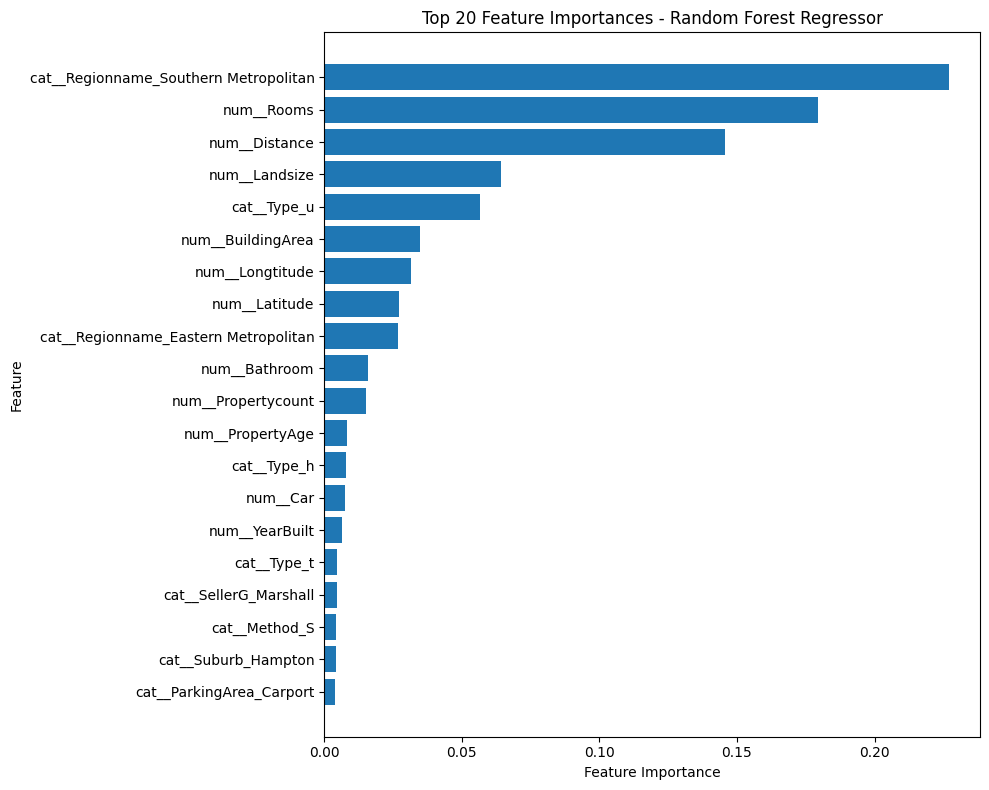

In [175]:
import matplotlib.pyplot as plt
# Select the top 20 features
top_features = importance_df.head(20)
plt.figure(figsize=(10, 8))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Random Forest Regressor")
plt.tight_layout()
plt.show()

## 5.15 Model Evaluation Visualizations

### 5.15.1 Actual vs Predicted Plot

The Actual vs Predicted plot compares the observed house prices with the prices predicted by the selected regression model. A prediction that is closer to the diagonal reference line indicates better agreement between the actual and predicted values. The Random Forest Regressor is used for this visualization because it achieved the highest R² and the lowest RMSE and MAE among the evaluated regression models.

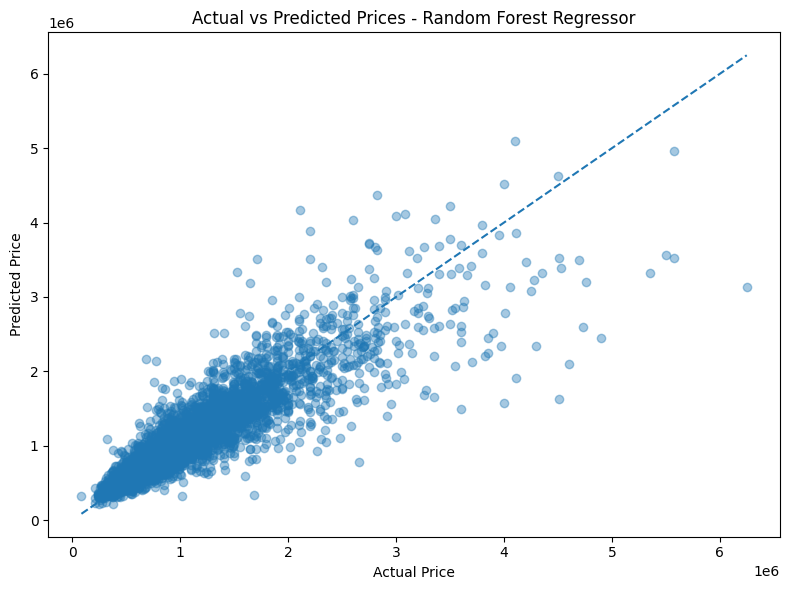

In [176]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_random_forest,
    alpha=0.4
)

# Reference line: perfect predictions
min_value = min(y_test.min(), y_pred_random_forest.min())
max_value = max(y_test.max(), y_pred_random_forest.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices - Random Forest Regressor")
plt.tight_layout()
plt.show()

### Interpretation

Most predictions are distributed around the diagonal reference line, indicating that the Random Forest model captures a substantial portion of the relationship between the input features and property prices.

The dispersion from the diagonal shows that prediction errors remain, particularly for some higher-priced properties. This is consistent with the RMSE being higher than the MAE, as larger prediction errors have a greater effect on RMSE.

### 5.15.2 Residual Plot

A residual is the difference between the actual target value and the value predicted by the model. The residual plot is used to examine whether the prediction errors are randomly distributed around zero. A well-behaved residual plot should show residuals scattered around the zero reference line without a clear systematic pattern.

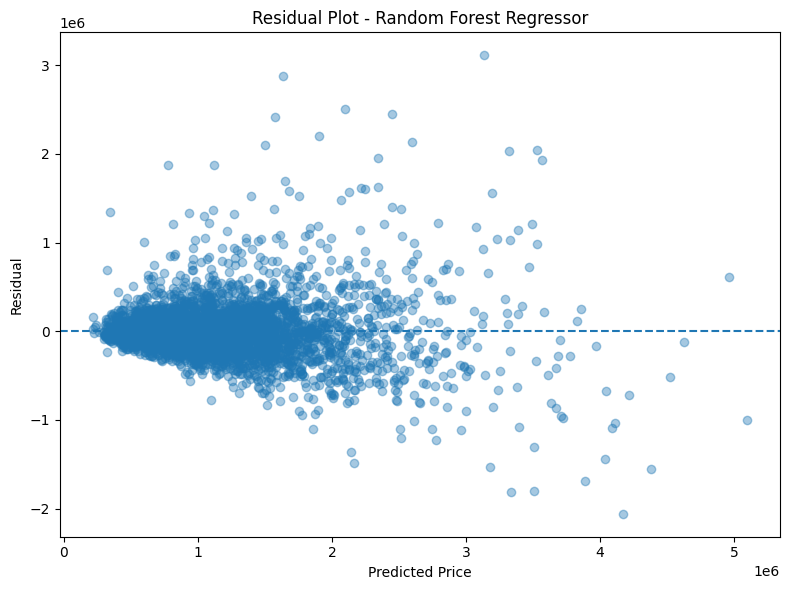

In [177]:
residuals = y_test - y_pred_random_forest

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_random_forest,
    residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot - Random Forest Regressor")
plt.tight_layout()
plt.show()

### Interpretation

The residuals are generally distributed around the zero reference line, indicating that the model does not show a strong systematic bias across the majority of predictions.

However, the spread of residuals becomes larger for some higher predicted prices, suggesting that the model's prediction error is not completely uniform across the price range. A small number of observations also produce relatively large positive or negative residuals.

## 5.16 Final Model Discussion

The regression analysis evaluated ten algorithms using the same training-test split and preprocessing strategy. The final comparison showed that the ensemble tree-based models achieved stronger predictive performance than the linear and single-tree approaches.

Random Forest achieved the highest held-out test-set R² of **0.7958**, with an RMSE of **281,394.33** and an MAE of **164,873.02**. Gradient Boosting also performed strongly, achieving an R² of **0.7824**. Five-fold cross-validation further showed reasonably consistent performance for both models.

The feature importance analysis indicated that location, number of rooms, distance, land size, and building-related characteristics contributed substantially to the Random Forest predictions. The actual-versus-predicted and residual plots provided additional evidence about the model's prediction accuracy and remaining errors.

Based on the combined test-set evaluation, cross-validation results, feature importance analysis, and visual diagnostics, the Random Forest Regressor was selected as the model used for the final evaluation visualizations.